In [3]:
! pip3 install -r requirements.txt

  Using cached fastai-2.8.8-py3-none-any.whl.metadata (8.7 kB)
  Using cached gradio-6.24.0-py3-none-any.whl.metadata (17 kB)
  Using cached fastdownload-0.0.7-py3-none-any.whl.metadata (5.5 kB)
  Using cached fastcore-2.2.13-py3-none-any.whl.metadata (9.1 kB)
  Using cached fasttransform-0.0.2-py3-none-any.whl.metadata (7.6 kB)
  Using cached torchvision-0.28.0-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (5.6 kB)
  Using cached matplotlib-3.11.1-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (80 kB)
  Using cached pandas-3.0.5-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached pyyaml-6.0.3-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
  Using cached fastprogress-1.1.6-py3-none-any.whl.metadata (4.9 kB)
  Using cached pillow-12.3.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.1 kB)
  Using cached scikit_learn-1.9.0-cp313-cp313-manylinux_2_27_x

In [4]:
from fastai.vision.all import *
from fastcore.all import *

Test that we can open an image

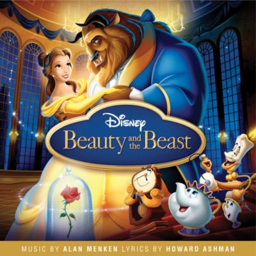

In [16]:
img_ex = 'dataset/cd/1991/Beauty and the Beast_1991.jpg'
im = Image.open(img_ex)
im.to_thumb(256,256)

In [60]:
formats = ['vinyl', 'cassette_tape', 'cd', 'digital_download', 'streaming']

for f in formats:
    dest = f'dataset/{f}'
    resize_images(dest, max_size=400, dest=dest, recurse=True)

In [61]:
def get_format_label(path):
    """Get the format label (the grandparent folder) from image path"""
    return path.parent.parent.name

def get_grouped_format(path):
    """
    Group formats into 3 categories based on form factor:
    - vinyl: large physical format
    - physical_compact: small physical format (cassette_tape and cd)
    - digital: digital download and streaming
    """
    format = get_format_label(path)

    if format == 'vinyl':
        return 'vinyl'
    elif format in ['cassette_tape', 'cd']:
        return 'physical_compact'
    elif format in ['digital_download', 'streaming']:
        return 'digital'
    else:
        return format  # fallback

Train the model

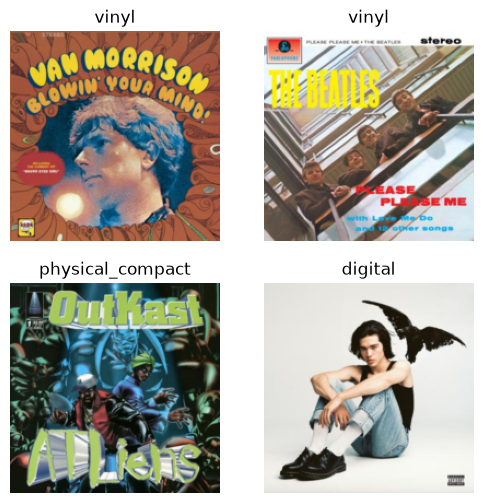

In [ ]:
path = 'dataset'

dls3 = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=get_grouped_format,
    item_tfms=[Resize(224, method='squish')]
).dataloaders(path, bs=16)

dls3.show_batch(max_n=4)

<div></div>

SuggestedLRs(slide=0.0002290867705596611, valley=0.0003981071640737355)

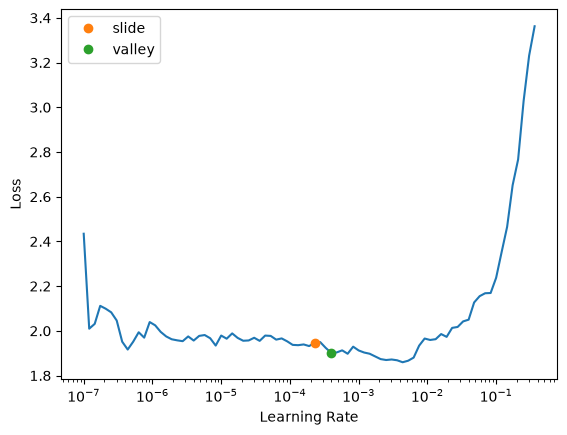

In [63]:
learn3 = vision_learner(dls3, resnet18, metrics=error_rate)
lr3 = learn3.lr_find(suggest_funcs=(slide, valley))
lr3

Verify base model performance

In [ ]:
base_model3_perf = learn3.validate()
base_model3_perf  # loss, error rate

[3.8972532749176025, 0.5420875549316406]

In [67]:
learn3.fine_tune(4, base_lr=0.00025)

epoch,train_loss,valid_loss,error_rate,time
0,1.492872,1.199214,0.518519,00:09


epoch,train_loss,valid_loss,error_rate,time
0,1.296757,1.165940,0.515152,00:13
1,1.212291,1.127615,0.478114,00:13
2,1.086966,1.135962,0.461279,00:14
3,0.951578,1.115739,0.471380,00:13


Make predictions

This is a digital.
{'digital': 0.9647021293640137, 'physical_compact': 0.00895928405225277, 'pre_vinyl': 0.014784757047891617, 'vinyl': 0.011553825810551643}


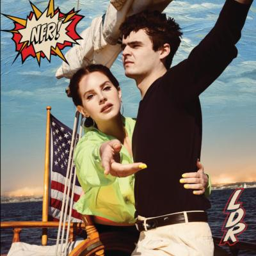

In [57]:
img_ex = 'dataset/streaming/2019/Norman Fucking Rockwell!_2019.jpg'
img_ex
pred, _, probs = learn3.predict(PILImage.create(img_ex))
print(f'This is a {pred}.')
print(dict(zip(learn3.dls.vocab, map(float, probs))))
im = Image.open(img_ex)
im.to_thumb(256, 256)

Export model

In [68]:
from pathlib import Path
Path('models').mkdir(exist_ok=True)

In [69]:
learn3.export('models/model_3format.pkl')
print('Exported 3-format model')

Exported 3-format model


Train 5 format model

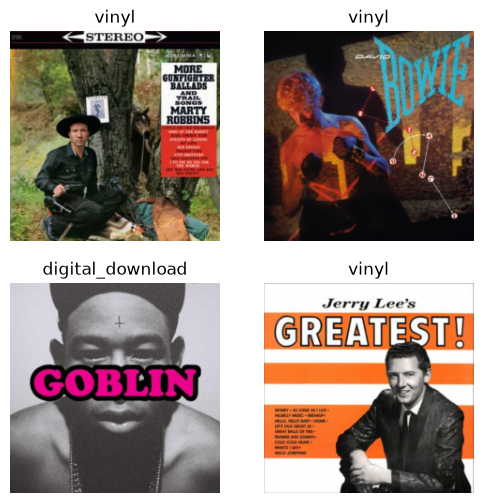

In [92]:
dls5 = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=get_format_label,
    item_tfms=[Resize(224, method='squish')]
).dataloaders(path, bs=16)

dls5.show_batch(max_n=4)

<div></div>

SuggestedLRs(slide=0.0020892962347716093, valley=0.001737800776027143)

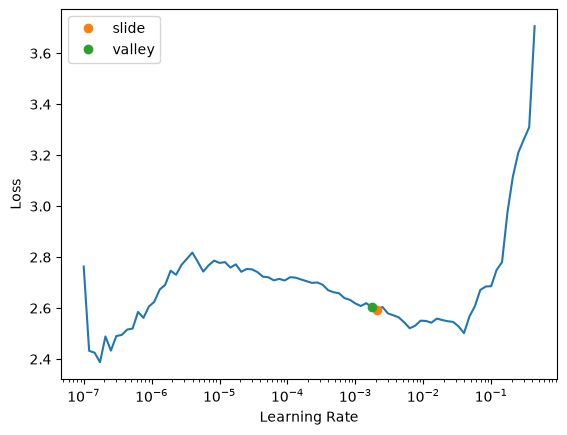

In [87]:
learn5= vision_learner(dls5, resnet18, metrics=error_rate)
learn5.lr_find(suggest_funcs=(slide, valley))

In [88]:
base_model5_perf = learn5.validate()
base_model5_perf  # loss, error rate

[3.231585741043091, 0.7205387353897095]

In [89]:
learn5.fine_tune(4, base_lr=0.002)

epoch,train_loss,valid_loss,error_rate,time
0,2.342293,1.698885,0.558923,00:14


epoch,train_loss,valid_loss,error_rate,time
0,1.573954,1.525481,0.471380,00:18
1,1.090542,1.710250,0.461279,00:20
2,0.662508,1.581574,0.471380,00:18
3,0.357740,1.568944,0.451178,00:19


In [90]:
learn5.export('models/model_5format.pkl')
print('Exported 5-format model')

Exported 5-format model


In [91]:
learn5.model

Sequential(
  (0): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=T